# Incorporating the *field cancerization effect* to improve modeling of untreated cancer growth

Supporting-information notebook. It reproduces the numerical analyses described in the manuscript from the data and reported parameter values included in this repository.


## 1. Environment and reproducibility

All stochastic operations use the fixed seed defined in `src.methods.RNG_SEED`. Model functions and plotting routines are kept in importable modules so that this notebook remains a concise, executable record of the analysis.


In [1]:
from importlib.metadata import version

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

from src import data, methods

print({
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "seed": methods.RNG_SEED,
})


{'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.15.3', 'matplotlib': '3.10.0', 'seed': 20260814}


## 2. Breast-cancer observations

The principal dataset comprises 13 measurements over days 1–13. Volume is expressed in cm³ and converted internally to cancer-cell population using the stated density of $10^7$ cells/cm³ when solving the models.


In [2]:
breast_data, _, _ = data.load_breast_data()
breast_data


,time,volume
0,1.0,0.40
1,2.0,0.65
2,3.0,0.79
3,4.0,0.93
4,5.0,1.06
5,6.0,1.21
6,7.0,1.39
7,8.0,1.57
8,9.0,1.85
9,10.0,2.21


## 3. Mathematical formulations

The implementation contains the original and reparameterized versions of both models:

- Baseline: $dC/dt=rC(1-C/K)-aK_TC+\lambda_{ST}C/2$.
- Reparameterized baseline: $dC/dt=m_1C-m_2C^2$.
- Extended FCE: the baseline equation plus $\lambda_NN$, with $dN/dt=\gamma'C-\gamma N$.
- Reparameterized FCE: $dC/dt=m_1C-m_2C^2+\lambda_NN$ and the same equation for $N$.

The original parameterizations are structurally redundant. They are retained only to reproduce the comparisons in the manuscript; inference should use the reparameterized forms. For a constant state rescaling $C_V=C/s$, $N_V=N/s$ in the reparameterized extended system, the quadratic coefficient transforms as $m_{2,V}=m_2s$ while $m_1$, $\lambda_N$, $\gamma$, and $\gamma'$ are unchanged.


In [3]:
reported_parameters = pd.DataFrame({
    "parameter": data.PARAMETER_SYMBOLS,
    "estimate": data.EXTENDED_INITIAL_PARAMS,
    "lower": data.EXTENDED_INITIAL_INTERVALS[:, 0],
    "upper": data.EXTENDED_INITIAL_INTERVALS[:, 1],
    "unit": data.PARAMETER_UNITS,
})
reported_parameters


,parameter,estimate,lower,upper,unit
0,r,3.913000e-01,3.910000e-01,3.916000e-01,day^-1
1,1/K,6.666667e-09,6.666667e-09,6.666667e-09,cell^-1
2,aK_T,1.675000e+00,1.670000e+00,1.680000e+00,day^-1
3,lambda_ST,1.183500e+00,1.181000e+00,1.186000e+00,day^-1
4,lambda_N,2.116200e+00,2.116000e+00,2.116400e+00,day^-1
5,gamma,1.824000e+00,1.821000e+00,1.827000e+00,day^-1
6,gamma_prime,8.135000e-01,8.130000e-01,8.140000e-01,day^-1


In [4]:
scale_check = pd.DataFrame(
    {
        "parameter": ["m1", "m2", "lambda_N", "gamma", "gamma_prime"],
        "cell_scale": data.EXTENDED_REPARAM_PARAMS,
        "volume_scale_s_equals_rho": methods.rescale_reparam_extended(
            data.EXTENDED_REPARAM_PARAMS, data.CELL_DENSITY
        ),
    }
)
scale_check


,parameter,cell_scale,volume_scale_s_equals_rho
0,m1,-6.915000e-01,-0.6915
1,m2,2.610000e-09,0.0261
2,lambda_N,2.116200e+00,2.1162
3,gamma,1.824000e+00,1.8240
4,gamma_prime,8.135000e-01,0.8135


## 4. Breast-cancer comparison and admissible parameter sampling

The green region is computed from candidate parameter vectors sampled inside the reported one-dimensional parameter intervals and then filtered by the practical admissibility criterion $\mathrm{MSE}(\theta) \le 0.004$. The tolerance is empirical; it is not a confidence interval, Bayesian posterior criterion, MCMC threshold, or probabilistic coverage statement.


{'epsilon': 0.004, 'candidate_vectors': 1000, 'retained_vectors': 656, 'max_retained_MSE': 0.003999874750235551}


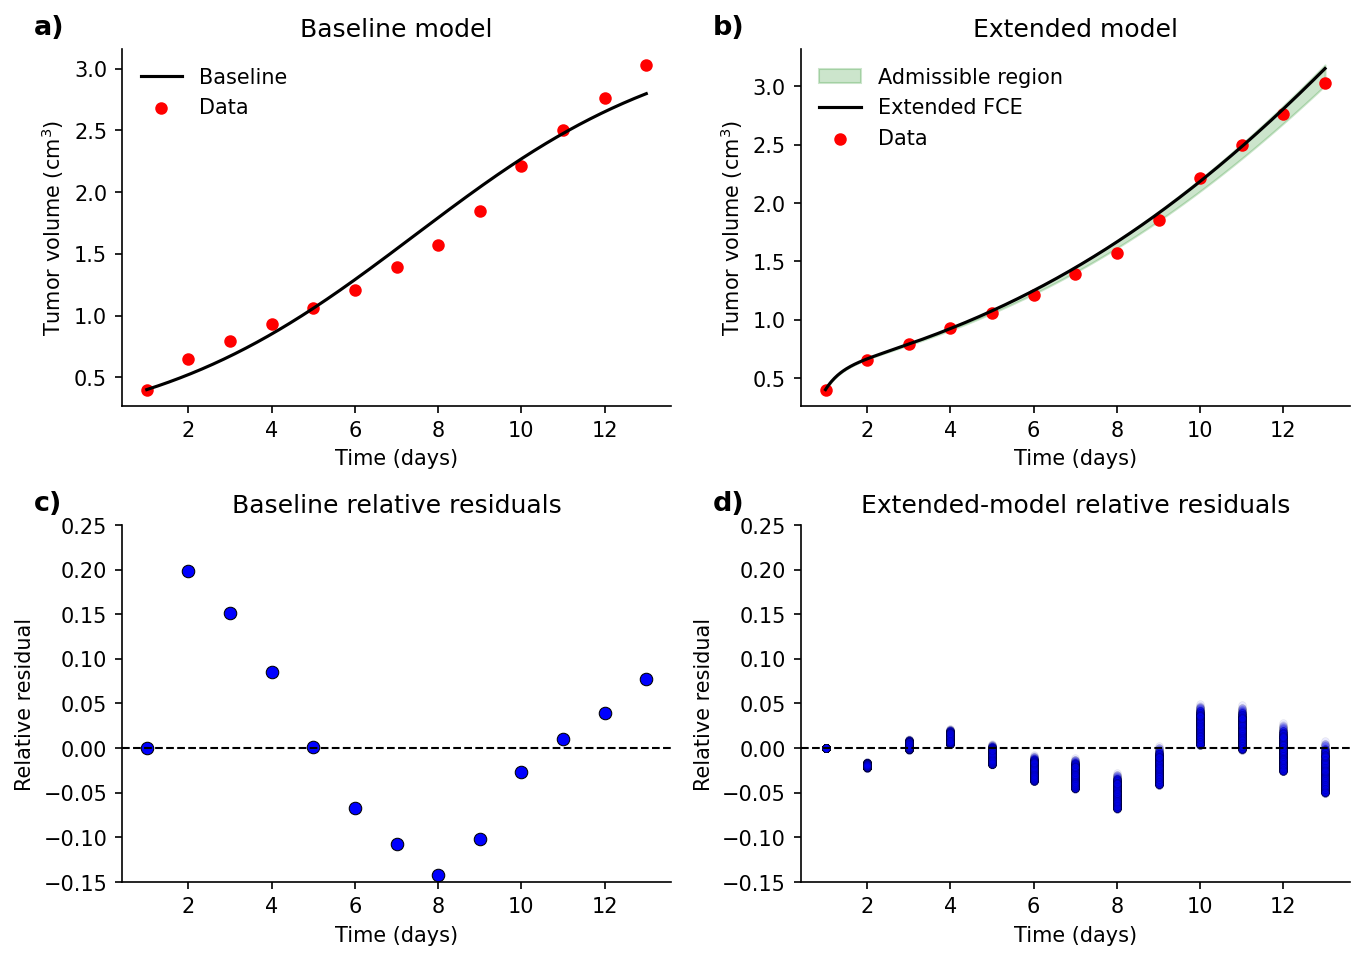

In [5]:
candidates, retained, retained_mse = methods.admissible_parameter_sample()
print({
    "epsilon": data.ADMISSIBLE_MSE_EPSILON,
    "candidate_vectors": len(candidates),
    "retained_vectors": len(retained),
    "max_retained_MSE": float(retained_mse.max()),
})

figure_3 = methods.plot_breast_comparison()
plt.show()


### Relative residuals and information criteria

RSS, MSE, AIC, and BIC follow equations (10)–(13) of the manuscript. All four models use the same 13 observations and response scale.


In [6]:
comparison = methods.model_comparison_table()
comparison.round({"RSS": 6, "MSE": 6, "AIC": 2, "BIC": 2})


,k,RSS,MSE,AIC,BIC
Model,,,,,
Baseline (original),4,0.221337,0.017026,-44.95,-42.69
Baseline (reparameterized),2,0.221337,0.017026,-48.95,-47.82
Extended FCE (initial),7,0.035517,0.002732,-62.74,-58.78
Extended FCE (reparameterized),5,0.039735,0.003057,-65.28,-62.45


### Audit against manuscript Table 5

The manuscript values are compared explicitly with the values recomputed from the dataset declared in the Methods section ($V(1)=0.40$ cm³). A nonzero difference identifies a manuscript–data inconsistency rather than an execution failure.


In [7]:
manuscript_table_5 = pd.DataFrame(
    {
        "MSE": [0.017173, 0.017173, 0.002860, 0.003184],
        "AIC": [-44.84, -48.84, -62.14, -64.74],
        "BIC": [-42.58, -47.71, -58.18, -61.92],
    },
    index=comparison.index,
)
comparison[["MSE", "AIC", "BIC"]].round(6) - manuscript_table_5


,MSE,AIC,BIC
Model,,,
Baseline (original),-0.000147,-0.109248,-0.109451
Baseline (reparameterized),-0.000147,-0.109248,-0.109349
Extended FCE (initial),-0.000128,-0.595182,-0.600537
Extended FCE (reparameterized),-0.000127,-0.536048,-0.531301


In [8]:
delta_aic = (
    comparison.loc["Baseline (reparameterized)", "AIC"]
    - comparison.loc["Extended FCE (reparameterized)", "AIC"]
)
print({"delta_AIC_full_precision": float(delta_aic)})


{'delta_AIC_full_precision': 16.32679951084944}


## 5. Exploratory cross-cancer analysis

The following plots reproduce the six independently parameterized trajectories. These heterogeneous datasets assess descriptive flexibility only; they do not validate a universal biological mechanism or a common parameter set.

**Current computational scale:** the breast observations are stored in cm³ and converted through $V_{mm^3}=C/10^7	imes1000$ only for the cross-cancer display. The five non-breast fits operate directly on absolute tumor-volume scales in mm³ with plotting scale factor 1.0. The current code does not normalize these trajectories to their maxima. Gastric-cancer observations were digitized as relative tumor volume, $V/V_0$, and are stored here as absolute volume after multiplying by $V_0=100$ mm³; the raw relative values are preserved in `src/cancer_types/gastric_cancer/raw_relative_observations.csv`.


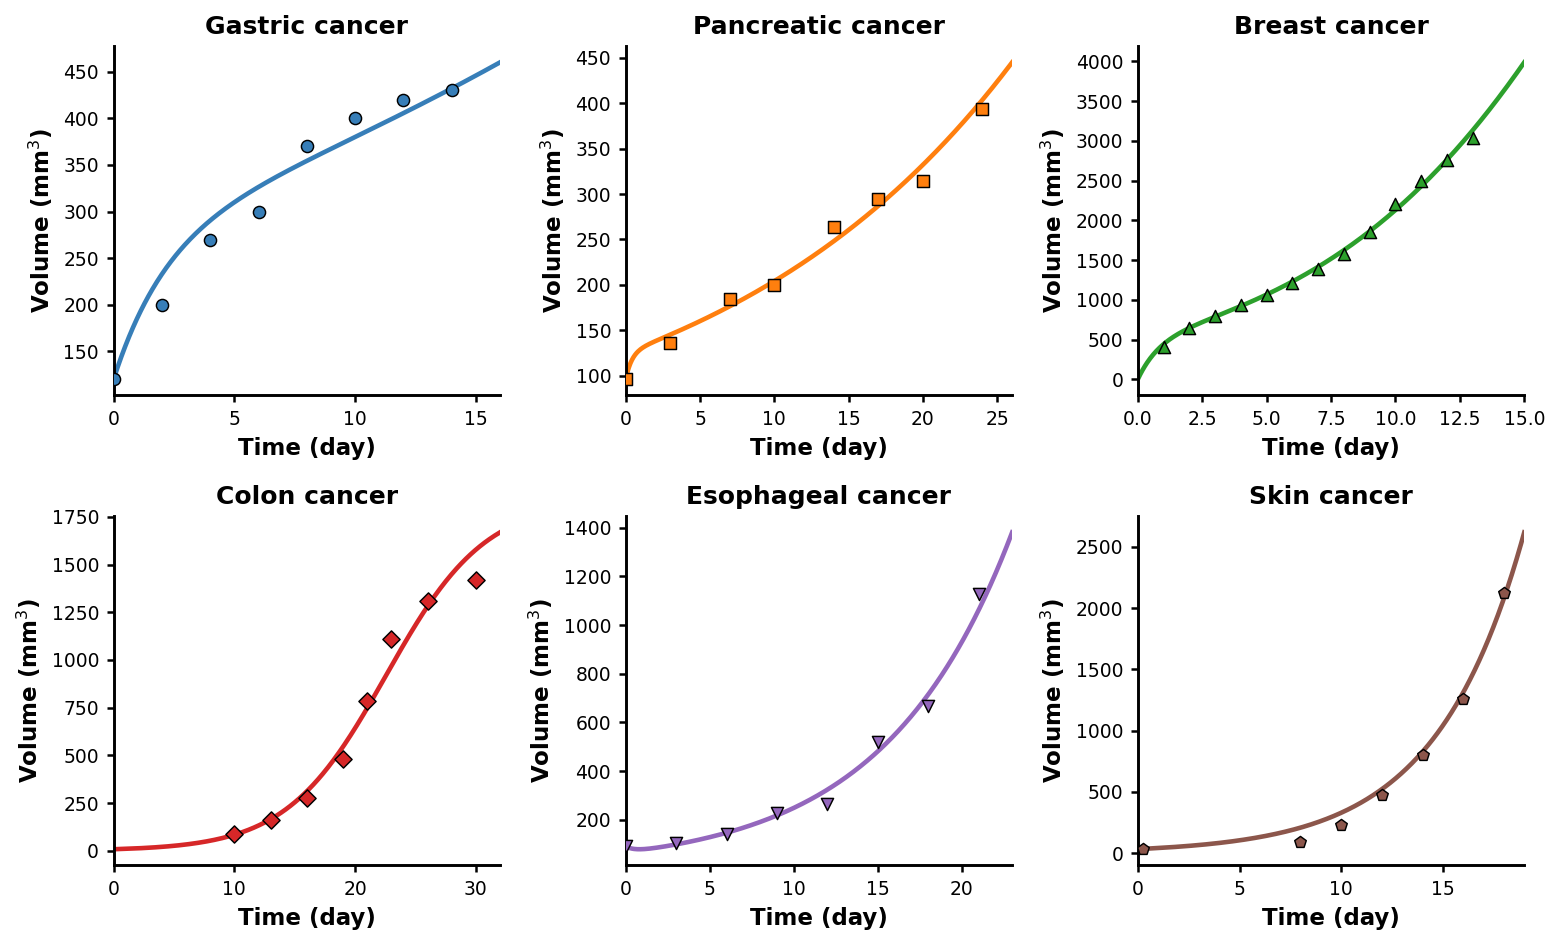

In [9]:
figure_4 = methods.plot_cross_cancer()
plt.show()


## 6. Initial-condition scenarios

This reproduces manuscript Figure 5. The left panel shows the stored scenario-specific fits when the initial time is fixed at the first observation. The right panel uses the stored shifted-time fit with the effective optimization-derived temporal offset $t_0=-0.2162$ day. This offset is not interpreted as a physical tumor-onset time or a biological pre-inoculation interval. These are stored optimization-derived values, not a new optimization performed by this notebook.


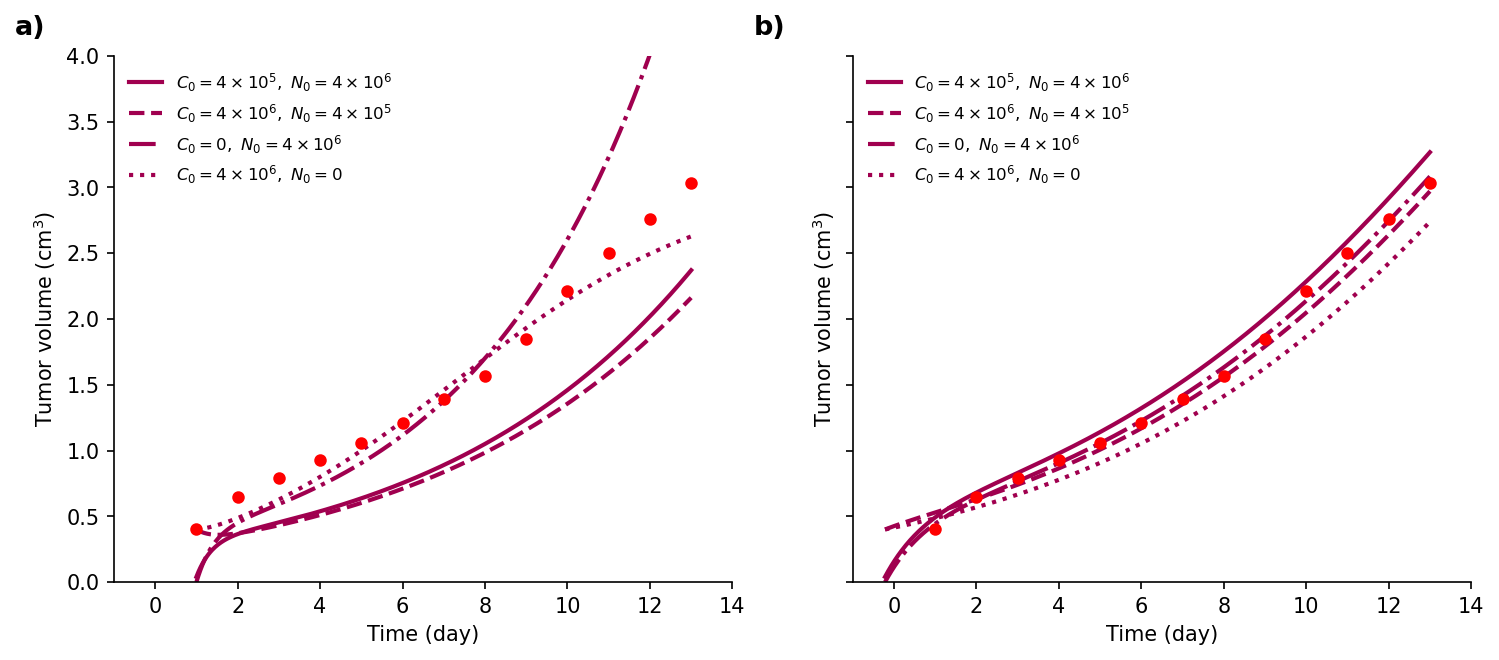

In [10]:
figure_initial_conditions = methods.plot_initial_condition_scenarios()
plt.show()


In [11]:
initial_condition_parameters = methods.export_initial_condition_parameters()
initial_condition_parameters


,scenario_description,temporal_initialization,C0,N0,r,inv_K,aK_T,lambda_ST,lambda_N,gamma,gamma_prime,m1,m2,t0,MSE,parameter_source
0,Predominance of normal preconditioned cells,fixed initial time,400000.0,4000000.0,0.39130,1.801460e-09,1.6750,1.1835,2.1162,1.824,0.813500,-0.69195,7.049113e-10,NaN,0.301316,optimization-derived stored value
1,Predominance of normal preconditioned cells,optimized effective temporal offset,400000.0,4000000.0,0.26900,6.666667e-09,0.8883,1.5680,1.4500,1.077,0.003246,0.16470,1.793333e-09,-0.2162,0.015586,stored shared shifted-time value
2,Predominance of cancer cells,fixed initial time,4000000.0,400000.0,0.39130,3.244900e-09,1.6750,1.1835,2.1162,1.824,0.813500,-0.69195,1.269729e-09,NaN,0.393000,optimization-derived stored value
3,Predominance of cancer cells,optimized effective temporal offset,4000000.0,400000.0,0.26900,6.666667e-09,0.8883,1.5680,1.4500,1.077,0.003246,0.16470,1.793333e-09,-0.2162,0.008210,stored shared shifted-time value
4,No initial cancer-cell population,fixed initial time,0.0,4000000.0,-0.07752,6.666667e-09,2.4680,2.5340,2.6420,1.003,0.680900,-1.27852,-5.168000e-10,NaN,0.499930,optimization-derived stored value
5,No initial cancer-cell population,optimized effective temporal offset,0.0,4000000.0,0.26900,6.666667e-09,0.8883,1.5680,1.4500,1.077,0.003246,0.16470,1.793333e-09,-0.2162,0.001735,stored shared shifted-time value
6,No initial preconditioned-cell population,fixed initial time,4000000.0,0.0,1.69000,6.666667e-09,2.6060,2.0470,0.2092,2.267,2.589000,0.10750,1.126667e-08,NaN,0.028147,optimization-derived stored value
7,No initial preconditioned-cell population,optimized effective temporal offset,4000000.0,0.0,0.26900,6.666667e-09,0.8883,1.5680,1.4500,1.077,0.003246,0.16470,1.793333e-09,-0.2162,0.050437,stored shared shifted-time value


## 7. Numerical fitting API

`methods.fit_model` provides seeded basin hopping with bounded L-BFGS-B local minimization. The notebook runs a lightweight deterministic optimization smoke test so that the fitting path is actually exercised. This smoke test is not used to replace the stored manuscript parameter sets and does not reconstruct every historical optimization run. Any new inference run should record its model formulation, bounds, iteration count, seed, fitted parameters, and objective value.


In [12]:
import importlib
from src import methods as methods

methods = importlib.reload(methods)
fitting_smoke_test = methods.fitting_smoke_test()
fitting_smoke_test


{'start_MSE': 0.05408282510140548,
 'smoke_test_MSE': 0.009298880481052759,
 'stored_baseline_reparam_MSE': 0.01702590820640087,
 'improved_from_start': True,
 'parameters': [0.27971688810057854, 7.314771127529912e-09]}

The helper below prints any `methods.fit_model(...)` result using the parameter notation used in the manuscript. It is left commented because users may choose which model and bounds to fit, but it is directly executable after assigning `result`.


In [13]:
# result = methods.fit_model(
#     methods.extended_reparam_rhs,
#     initial_guess=data.EXTENDED_REPARAM_PARAMS,
#     bounds=[(-2.0, 1.0), (0.0, 1e-7), (0.0, 5.0), (0.0, 5.0), (0.0, 5.0)],
#     initial=data.BREAST_INITIAL_CONDITIONS,
#     niter=100,
# )
# methods.print_fit_result(
#     result,
#     model_name="Extended FCE (reparameterized)",
# )


## 8. Scope of reproduction

Successful execution verifies that the stored data can be loaded, all four breast-model formulations can be integrated, the reported metrics can be recomputed, and the three analysis figures can be generated. It does not by itself establish biological validity, practical identifiability, or statistical confidence coverage.
